In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATASET_PATH = BASE_DIR / "datasets" / "fabric_defect"

print("Dataset Path:", DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

Dataset Path: c:\Users\Veera Dinesh D\OneDrive\Documents\SilkTrace_Project\datasets\fabric_defect
Exists: True


In [3]:
classes = ["hole", "horizontal", "vertical"]

for cls in classes:
    folder = DATASET_PATH / cls
    count = len(list(folder.glob("*.jpg")))
    print(f"{cls}: {count} images")

hole: 184 images
horizontal: 136 images
vertical: 92 images


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    classes=["hole", "horizontal", "vertical"],
    shuffle=True
)

Found 331 images belonging to 3 classes.


In [6]:
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    classes=["hole", "horizontal", "vertical"],
    shuffle=False
)

Found 81 images belonging to 3 classes.


In [7]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [8]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    3,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 729ms/step - accuracy: 0.4199 - loss: 1.1470 - val_accuracy: 0.4568 - val_loss: 0.9969
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 552ms/step - accuracy: 0.5045 - loss: 1.0594 - val_accuracy: 0.5309 - val_loss: 0.9485
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 599ms/step - accuracy: 0.4773 - loss: 1.0701 - val_accuracy: 0.5556 - val_loss: 0.8892
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 552ms/step - accuracy: 0.5317 - loss: 0.9460 - val_accuracy: 0.5679 - val_loss: 0.8897
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 557ms/step - accuracy: 0.5680 - loss: 0.9338 - val_accuracy: 0.6296 - val_loss: 0.8555
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.6103 - loss: 0.8533 - val_accuracy: 0.6790 - val_loss: 0.7953
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 521ms/step - accuracy: 0.6344 - loss: 0.8171 - val_accuracy: 0.6296 - val_loss: 0.8087
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 515ms/step - accuracy: 0.6284 - loss: 0.8389 - val_accu

In [12]:
model.save(BASE_DIR / "models" / "fabric_defect_model.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


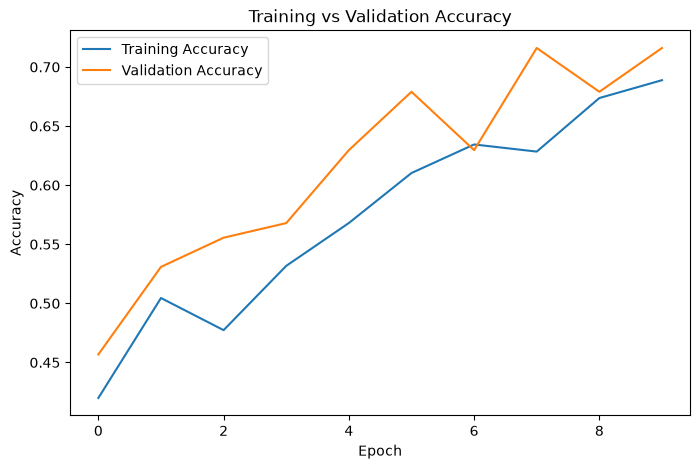

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

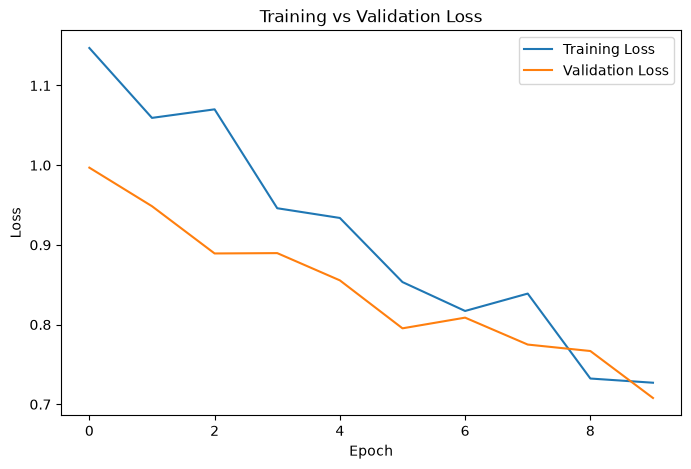

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [15]:
# Unfreeze the last 30 layers of the base model

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 753ms/step - accuracy: 0.5408 - loss: 0.9588 - val_accuracy: 0.7160 - val_loss: 0.7257
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.6375 - loss: 0.7804 - val_accuracy: 0.7160 - val_loss: 0.6929
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 587ms/step - accuracy: 0.7221 - loss: 0.7076 - val_accuracy: 0.7531 - val_loss: 0.6839
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.7069 - loss: 0.6746 - val_accuracy: 0.7407 - val_loss: 0.6781
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 624ms/step - accuracy: 0.8036 - loss: 0.5550 - val_accuracy: 0.7160 - val_loss: 0.6503
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 596ms/step - accuracy: 0.7704 - loss: 0.5909 - val_accuracy: 0.7531 - val_loss: 0.6259
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 630ms/step - accuracy: 0.7885 - loss: 0.5492 - val_accuracy: 0.7284 - val_loss: 0.6726
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 597ms/step - accuracy: 0.8187 - loss: 0.4939 - val_accu

In [18]:
from sklearn.metrics import classification_report
import numpy as np

validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 544ms/step
              precision    recall  f1-score   support

        hole       0.69      0.94      0.80        36
  horizontal       0.83      0.70      0.76        27
    vertical       0.89      0.44      0.59        18

    accuracy                           0.75        81
   macro avg       0.80      0.70      0.72        81
weighted avg       0.78      0.75      0.74        81



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[34  1  1]
 [ 8 19  0]
 [ 7  3  8]]


In [20]:
model.save(BASE_DIR / "models" / "fabric_defect_model.keras")

print("✅ Fabric Defect Model Saved Successfully!")

✅ Fabric Defect Model Saved Successfully!


In [21]:
print(train_generator.class_indices)

{'hole': 0, 'horizontal': 1, 'vertical': 2}


In [22]:
print(train_generator.class_indices)

{'hole': 0, 'horizontal': 1, 'vertical': 2}
